# Parte 3 — Analisis Cuantitativo: Dependencias y Vulnerabilidades

Consume los archivos generados por el analizador y produce el analisis cuantitativo.

**Antes de ejecutar este notebook**, asegurate de haber corrido el analizador:
```
python analizador_project/scripts/main.py --org <org> --output-root ./workspace
```

Los archivos esperados son:
```
workspace/reports/<org>/
    analysis_report.json
    analysis_report.csv
    vulnerabilities.csv
workspace/sboms/<org>/
    sbom_*.cyclonedx.json
    *-grype-raw.json
```

## 0. Setup

In [19]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ajusta ORG y WORKSPACE_ROOT si es necesario
ORG            = 'encode'
WORKSPACE_ROOT = Path('workspace')

REPORTS_DIR = WORKSPACE_ROOT / 'reports' / ORG
SBOMS_DIR   = WORKSPACE_ROOT / 'sboms'   / ORG

# Verificar archivos de entrada
required = [
    REPORTS_DIR / 'analysis_report.json',
    REPORTS_DIR / 'analysis_report.csv',
    REPORTS_DIR / 'vulnerabilities.csv',
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Faltan archivos de entrada:\n' +
        '\n'.join(f'  {p}' for p in missing) +
        '\n\nEjecuta primero: python analizador_project/scripts/main.py --org ' + ORG + ' --output-root ./workspace'
    )

# Paleta de colores por severidad
SEV_COLORS = {'CRITICAL':'#ff4d4d','HIGH':'#ff8c00','MEDIUM':'#ffd700','LOW':'#4fc3f7'}

plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'text.color':'#e6edf3',
    'axes.labelcolor':'#e6edf3',  'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#30363d',
    'grid.alpha':0.5,             'font.family':'monospace',
    'axes.titlecolor':'#58a6ff',  'legend.facecolor':'#21262d',
    'legend.edgecolor':'#30363d',
})

print('Archivos encontrados:')
for p in required:
    print(f'  {p.name}')

Archivos encontrados:
  analysis_report.json
  analysis_report.csv
  vulnerabilities.csv


## 1. Carga de datos

In [20]:
with open(REPORTS_DIR / 'analysis_report.json') as f:
    report = json.load(f)

df_repos = pd.read_csv(REPORTS_DIR / 'analysis_report.csv')
df_vulns = pd.read_csv(REPORTS_DIR / 'vulnerabilities.csv')

# Componentes desde los SBOMs
rows = []
for sbom_file in sorted(SBOMS_DIR.glob('sbom_*.cyclonedx.json')):
    sbom = json.loads(sbom_file.read_text())
    repo = sbom['metadata']['component']['name']
    props = {p['name']: p['value'] for p in sbom['metadata'].get('properties', [])}
    for comp in sbom.get('components', []):
        rows.append({
            'repo':    repo,
            'package': comp['name'],
            'version': comp['version'],
            'scope':   comp.get('scope', 'required'),
            'ecosystem': props.get('ecosystem', 'unknown'),
        })
df_comps = pd.DataFrame(rows)

print(f'Repositorios    : {len(df_repos)}')
print(f'Componentes     : {len(df_comps)}')
print(f'Hallazgos CVE   : {len(df_vulns)}')
print(f'CVEs unicos     : {df_vulns["cve_id"].nunique() if len(df_vulns) else 0}')
print()
print(df_repos[['repo_name','ecosystem','n_components','n_vulnerabilities','risk_score']].to_string(index=False))

Repositorios    : 3
Componentes     : 32
Hallazgos CVE   : 47
CVEs unicos     : 47

              repo_name ecosystem  n_components  n_vulnerabilities  risk_score
  django-rest-framework    python             1                 43      100.00
                  httpx    python            20                  4        3.58
rest-framework-tutorial    python            11                  0        0.00


## 2. Analisis de dependencias

In [21]:
# Estadisticas descriptivas
print('=== Componentes por repositorio ===')
print(df_repos[['repo_name','n_components','n_direct','n_optional']].to_string(index=False))
print()
s = df_repos['n_components']
print(f'Media: {s.mean():.1f}   Mediana: {s.median():.1f}   Min: {s.min()}   Max: {s.max()}')
print()
if len(df_comps):
    shared = df_comps.groupby('package')['repo'].nunique()
    print(f'Paquetes unicos          : {df_comps["package"].nunique()}')
    print(f'Compartidos en >1 repo   : {(shared > 1).sum()}')
    print()
    if (shared > 1).any():
        print('Paquetes compartidos:')
        print(shared[shared > 1].sort_values(ascending=False).to_string())

=== Componentes por repositorio ===
              repo_name  n_components  n_direct  n_optional
  django-rest-framework             1         1           0
                  httpx            20        20           0
rest-framework-tutorial            11        11           0

Media: 10.7   Mediana: 11.0   Min: 1   Max: 20

Paquetes unicos          : 31
Compartidos en >1 repo   : 1

Paquetes compartidos:
package
django    2


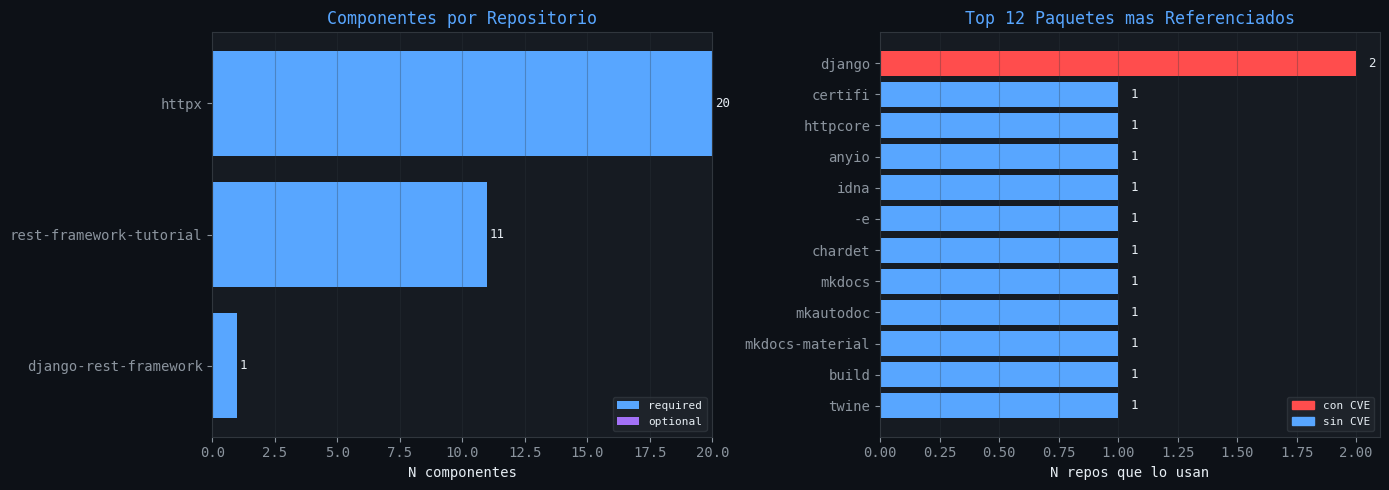

In [13]:
if len(df_comps) == 0:
    print('Sin datos de componentes.')
else:
    vuln_pkgs = set(df_vulns['package'].unique()) if len(df_vulns) else set()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d1117')

    # Componentes por repo (required vs optional)
    ax = axes[0]
    scope = df_comps.groupby(['repo','scope']).size().unstack(fill_value=0)
    for col in ['required','optional']:
        if col not in scope.columns: scope[col] = 0
    scope = scope.sort_values('required', ascending=True)
    ax.barh(scope.index, scope['required'], color='#58a6ff', label='required')
    ax.barh(scope.index, scope['optional'], left=scope['required'], color='#a371f7', label='optional')
    for i,(r,o) in enumerate(zip(scope['required'], scope['optional'])):
        ax.text(r+o+0.1, i, str(r+o), va='center', fontsize=9, color='#e6edf3')
    ax.set_title('Componentes por Repositorio')
    ax.set_xlabel('N componentes', color='#e6edf3')
    ax.set_facecolor('#161b22'); ax.grid(axis='x', alpha=0.3)
    ax.legend(labelcolor='#e6edf3', fontsize=8)

    # Top paquetes mas frecuentes
    ax = axes[1]
    top = df_comps['package'].value_counts().head(12)
    colors = ['#ff4d4d' if p in vuln_pkgs else '#58a6ff' for p in top.index]
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    for i,v in enumerate(top.values[::-1]):
        ax.text(v+0.05, i, str(v), va='center', fontsize=9, color='#e6edf3')
    ax.set_title('Top 12 Paquetes mas Referenciados')
    ax.set_xlabel('N repos que lo usan', color='#e6edf3')
    ax.set_facecolor('#161b22'); ax.grid(axis='x', alpha=0.3)
    ax.legend(handles=[
        mpatches.Patch(color='#ff4d4d', label='con CVE'),
        mpatches.Patch(color='#58a6ff', label='sin CVE'),
    ], labelcolor='#e6edf3', fontsize=8)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fig1_dependencias.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

## 3. Analisis de vulnerabilidades

In [14]:
if len(df_vulns) == 0:
    print('No se detectaron vulnerabilidades activas.')
    print('Esto puede significar que las dependencias estan actualizadas,')
    print('o que Grype no encontro matches contra su BD para las versiones presentes.')
else:
    sev = Counter(df_vulns['severity'])
    print(f'Total hallazgos     : {len(df_vulns)}')
    print(f'CVEs unicos         : {df_vulns["cve_id"].nunique()}')
    print(f'Paquetes afectados  : {df_vulns["package"].nunique()}')
    print(f'Repos afectados     : {df_vulns["repo"].nunique()}')
    print()
    for s in ['CRITICAL','HIGH','MEDIUM','LOW']:
        n = sev.get(s, 0)
        if n: print(f'  {s:<10}: {n:>3}  {"#"*n}')
    print()
    d = df_vulns['cvss']
    print(f'CVSS  media: {d.mean():.2f}   mediana: {d.median():.2f}   max: {d.max():.1f}')

Total hallazgos     : 47
CVEs unicos         : 47
Paquetes afectados  : 3
Repos afectados     : 2

  CRITICAL  :   3  ###
  HIGH      :  17  #################
  MEDIUM    :  19  ###################
  LOW       :   8  ########

CVSS  media: 6.57   mediana: 6.90   max: 9.8


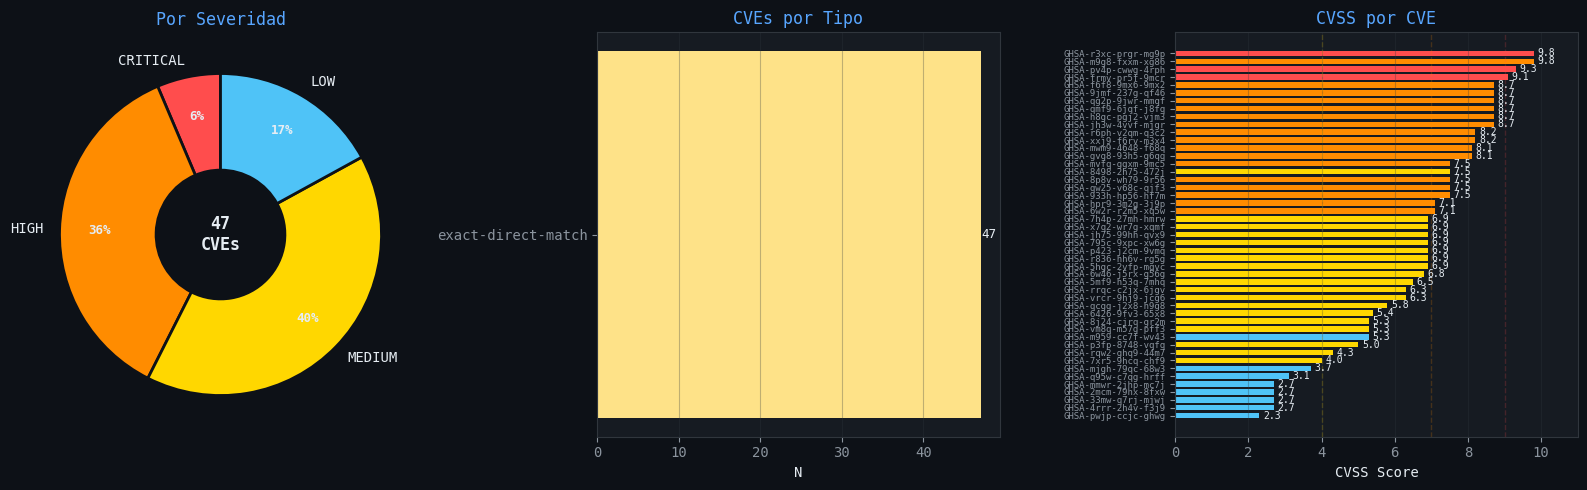

In [15]:
if len(df_vulns) == 0:
    print('Sin vulnerabilidades, omitiendo graficos.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor('#0d1117')

    # Donut por severidad
    ax = axes[0]
    sev_cnt = df_vulns['severity'].value_counts()
    sev_ord = [s for s in ['CRITICAL','HIGH','MEDIUM','LOW'] if s in sev_cnt.index]
    wedges, texts, autos = ax.pie(
        [sev_cnt[s] for s in sev_ord],
        labels=sev_ord, colors=[SEV_COLORS[s] for s in sev_ord],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(width=0.6, edgecolor='#0d1117', linewidth=2),
        textprops={'color':'#e6edf3','fontsize':10}, pctdistance=0.75,
    )
    for a in autos: a.set_fontsize(9); a.set_fontweight('bold')
    ax.text(0, 0, f'{len(df_vulns)}\nCVEs', ha='center', va='center',
            fontsize=12, fontweight='bold', color='#e6edf3')
    ax.set_title('Por Severidad'); ax.set_facecolor('#161b22')

    # CVEs por tipo de ataque
    ax = axes[1]
    tc = df_vulns['vuln_type'].value_counts().head(8)
    gcols = plt.cm.YlOrRd(range(50, 230, max(1, 180//len(tc))))
    bars = ax.barh(tc.index[::-1], tc.values[::-1], color=list(gcols)[::-1])
    for bar,v in zip(bars, tc.values[::-1]):
        ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                str(v), va='center', fontsize=9, color='#e6edf3')
    ax.set_title('CVEs por Tipo'); ax.set_xlabel('N', color='#e6edf3')
    ax.set_facecolor('#161b22'); ax.grid(axis='x', alpha=0.3)

    # CVSS por CVE unico
    ax = axes[2]
    df_u = df_vulns.drop_duplicates('cve_id').sort_values('cvss', ascending=True)
    bc = [SEV_COLORS[s] for s in df_u['severity']]
    bars2 = ax.barh(df_u['cve_id'], df_u['cvss'], color=bc, height=0.7)
    for x,lc in [(9.0,'#ff4d4d'),(7.0,'#ff8c00'),(4.0,'#ffd700')]:
        ax.axvline(x=x, color=lc, alpha=0.2, linestyle='--', linewidth=1)
    ax.set_xlim(0, 11); ax.set_xlabel('CVSS Score', color='#e6edf3')
    ax.set_title('CVSS por CVE'); ax.tick_params(axis='y', labelsize=6.5)
    ax.set_facecolor('#161b22'); ax.grid(axis='x', alpha=0.3)
    for bar,score in zip(bars2, df_u['cvss']):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                str(score), va='center', fontsize=7, color='#e6edf3')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'fig2_vulnerabilidades.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

## 4. Risk Score y priorizacion

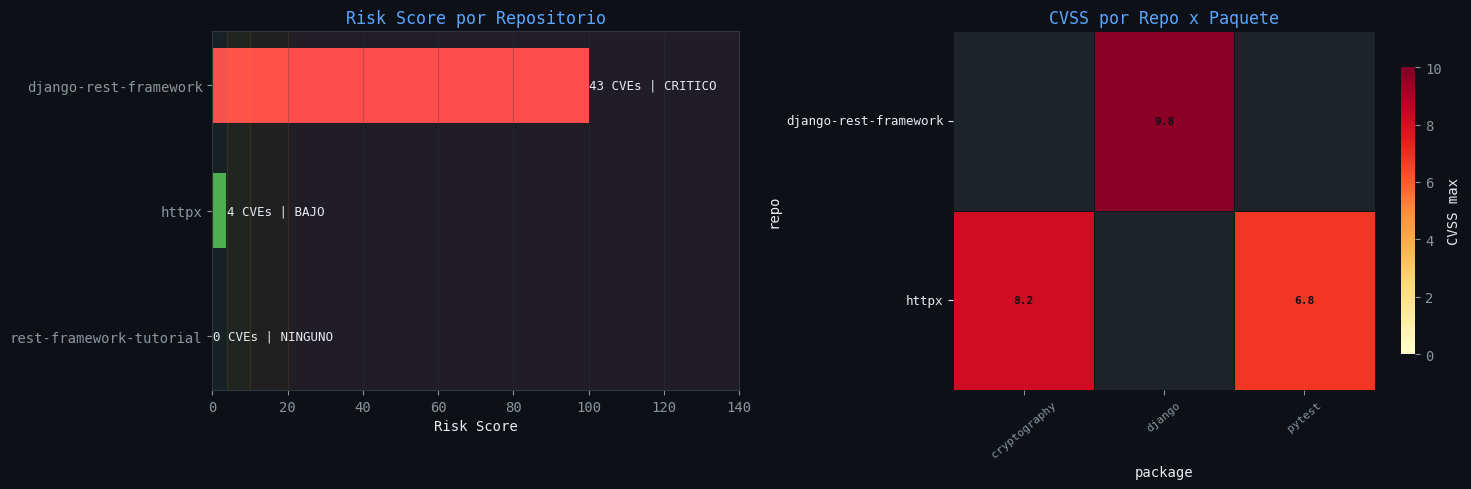

In [16]:
def risk_color(s):
    if s >= 20: return '#ff4d4d'
    if s >= 10: return '#ff8c00'
    if s >= 4:  return '#ffd700'
    if s > 0:   return '#4caf50'
    return '#4fc3f7'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')

# Risk Score por repo
ax = axes[0]
dr = df_repos.sort_values('risk_score', ascending=True)
bars = ax.barh(dr['repo_name'], dr['risk_score'],
               color=[risk_color(s) for s in dr['risk_score']], height=0.6)
xmax = max(dr['risk_score'].max() * 1.4, 25)
for xlo,xhi,lc in [(0,4,'#4caf50'),(4,10,'#ffd700'),(10,20,'#ff8c00'),(20,xmax,'#ff4d4d')]:
    ax.axvspan(xlo, min(xhi,xmax), alpha=0.05, color=lc)
for bar,(_,row) in zip(bars, dr.iterrows()):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{row['n_vulnerabilities']} CVEs | {row['risk_level']}",
            va='center', fontsize=9, color='#e6edf3')
ax.set_xlim(0, xmax)
ax.set_title('Risk Score por Repositorio')
ax.set_xlabel('Risk Score', color='#e6edf3')
ax.set_facecolor('#161b22'); ax.grid(axis='x', alpha=0.3)

# Mapa de calor si hay vulnerabilidades
ax = axes[1]
if len(df_vulns):
    pivot = df_vulns.groupby(['repo','package'])['cvss'].max().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
                linewidths=0.5, linecolor='#0d1117',
                annot_kws={'size':8,'color':'#0d1117','weight':'bold'},
                cbar_kws={'label':'CVSS max','shrink':0.8},
                vmin=0, vmax=10, mask=(pivot==0))
    sns.heatmap(pivot, ax=ax, cmap=['#21262d'], linewidths=0.5, linecolor='#0d1117',
                annot=False, cbar=False, mask=(pivot!=0), alpha=0.8)
    ax.set_title('CVSS por Repo x Paquete')
    ax.tick_params(axis='x', rotation=40, labelsize=8, colors='#8b949e')
    ax.tick_params(axis='y', rotation=0, labelsize=9, colors='#e6edf3')
    cbar = ax.collections[0].colorbar
    if cbar: cbar.ax.tick_params(colors='#8b949e')
else:
    ax.text(0.5, 0.5, 'Sin vulnerabilidades detectadas',
            ha='center', va='center', color='#e6edf3', fontsize=12,
            transform=ax.transAxes)
    ax.set_facecolor('#161b22'); ax.set_title('Mapa de Calor CVSS')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig3_riesgo.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Tabla de priorizacion de remediacion

In [17]:
if len(df_vulns) == 0:
    print('Sin vulnerabilidades activas.')
else:
    # Tabla priorizada por CVSS x repos_afectados
    df_prio = (
        df_vulns
        .groupby(['cve_id','package','severity','cvss','vuln_type'])
        .agg(
            repos_afectados=('repo','nunique'),
            repos=('repo', lambda x: ', '.join(sorted(x.unique())))
        )
        .reset_index()
    )
    df_prio['prioridad'] = df_prio['cvss'] * df_prio['repos_afectados']
    df_prio = df_prio.sort_values('prioridad', ascending=False).reset_index(drop=True)

    # Agregar version de correccion desde el reporte
    fix_map = {}
    for rd in report['repos']:
        for v in rd['vulnerabilities']:
            fix_map[v['cve_id']] = v['version_fix']
    df_prio['version_fix'] = df_prio['cve_id'].map(fix_map).fillna('?')

    cols = ['cve_id','package','version_fix','severity','cvss','repos_afectados','vuln_type']
    print(df_prio[cols].to_string(index=False))

             cve_id      package version_fix severity  cvss  repos_afectados          vuln_type
GHSA-m9g8-fxxm-xg86       django      4.2.17     HIGH   9.8                1 exact-direct-match
GHSA-r3xc-prgr-mg9p       django       4.2.1 CRITICAL   9.8                1 exact-direct-match
GHSA-pv4p-cwwg-4rph       django      4.2.15 CRITICAL   9.3                1 exact-direct-match
GHSA-frmv-pr5f-9mcr       django      4.2.26 CRITICAL   9.1                1 exact-direct-match
GHSA-f6f8-9mx6-9mx2       django      4.2.14     HIGH   8.7                1 exact-direct-match
GHSA-h8gc-pgj2-vjm3       django       4.2.6     HIGH   8.7                1 exact-direct-match
GHSA-jh3w-4vvf-mjgr       django       4.2.3     HIGH   8.7                1 exact-direct-match
GHSA-9jmf-237g-qf46       django      4.2.14     HIGH   8.7                1 exact-direct-match
GHSA-qmf9-6jqf-j8fq       django       4.2.7     HIGH   8.7                1 exact-direct-match
GHSA-qg2p-9jwr-mmqf       django      4.

## 6. Resumen

In [18]:
total_vulns = len(df_vulns)
sev_c = Counter(df_vulns['severity']) if total_vulns else Counter()

print('=' * 50)
print(f'  Organizacion    : {ORG}')
print(f'  Repos analizados: {len(df_repos)}')
print(f'  Componentes     : {len(df_comps)}')
print(f'  CVEs encontrados: {total_vulns}')
if total_vulns:
    for s in ['CRITICAL','HIGH','MEDIUM','LOW']:
        n = sev_c.get(s,0)
        if n: print(f'    {s:<10}: {n}')
    print(f'  CVSS promedio   : {df_vulns["cvss"].mean():.2f}')
    worst_row = df_vulns.loc[df_vulns['cvss'].idxmax()]
    print(f'  CVE mas critico : {worst_row["cve_id"]} ({worst_row["package"]} CVSS {worst_row["cvss"]})')
print('=' * 50)
print()
print('Figuras guardadas en:', REPORTS_DIR)
for f in sorted(REPORTS_DIR.glob('fig*.png')):
    print(f'  {f.name}')

  Organizacion    : encode
  Repos analizados: 3
  Componentes     : 32
  CVEs encontrados: 47
    CRITICAL  : 3
    HIGH      : 17
    MEDIUM    : 19
    LOW       : 8
  CVSS promedio   : 6.57
  CVE mas critico : GHSA-m9g8-fxxm-xg86 (django CVSS 9.8)

Figuras guardadas en: workspace/reports/encode
  fig1_dependencias.png
  fig2_vulnerabilidades.png
  fig3_riesgo.png
